In [65]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# import sys
from dotenv import load_dotenv
load_dotenv()

DATA_SOURCE_PATH = os.getenv("DATA_SOURCE_PATH", "../data/raw/")
HOUSE_DATASET_FILENAME = os.getenv("HOUSE_DATASET_FILENAME", "house_dataset.csv")
SOURCE_PATH = os.getenv("SOURCE_PATH", "../src/")

# Add src to path for custom modules
# sys.path.append(SOURCE_PATH)

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Environment setup complete!")

✅ Environment setup complete!


In [66]:
# Load your house price dataset
data_path = Path(DATA_SOURCE_PATH)
df = pd.read_csv(data_path / HOUSE_DATASET_FILENAME)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (9200, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           9200 non-null   object 
 1   price          9200 non-null   float64
 2   bedrooms       9200 non-null   float64
 3   bathrooms      9200 non-null   float64
 4   sqft_living    9200 non-null   int64  
 5   sqft_lot       9200 non-null   int64  
 6   floors         9200 non-null   float64
 7   waterfront     9200 non-null   int64  
 8   view           9200 non-null   int64  
 9   condition      9200 non-null   int64  
 10  sqft_above     9200 non-null   int64  
 11  sqft_basement  9200 non-null   int64  
 12  yr_built       9200 non-null   int64  
 13  yr_renovated   9200 non-null   int64  
 14  street         9200 non-null   object 
 15  city           9200 non-null   object 
 16  statezip       9200 non-null   object 
 17  country        9200 non-null   object 
dtypes: float

In [85]:
print("\n=== STATISTICAL SUMMARY ===")
print(df.describe(percentiles=[.01, .25, .5, .75, .99]))

# Check for missing values
print("\n=== MISSING VALUES ===")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
print(missing_info[missing_info['Missing Count'] > 0])


=== STATISTICAL SUMMARY ===
              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  9.200000e+03  9200.000000  9200.000000   9200.000000  9.200000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.225217  1.485252e+04   
std    5.638041e+05     0.908799     0.783738    963.131107  3.588249e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
1%     0.000000e+00     2.000000     1.000000    720.000000  1.026950e+03   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
99%    2.005220e+06     6.000000     4.500000   5180.100000  2.034555e+05   
max    2.659000e+07     9.000000     8.000000  13540.000000  1.074218e+06   

            floors   waterfront         view    condition   sqft_above  \
count  9200.000000  9200.000000  9200.000000  920

In [71]:
total_duplicates = df.duplicated().sum()
print(f"\nTotal duplicate rows: {total_duplicates}")


Total duplicate rows: 4598


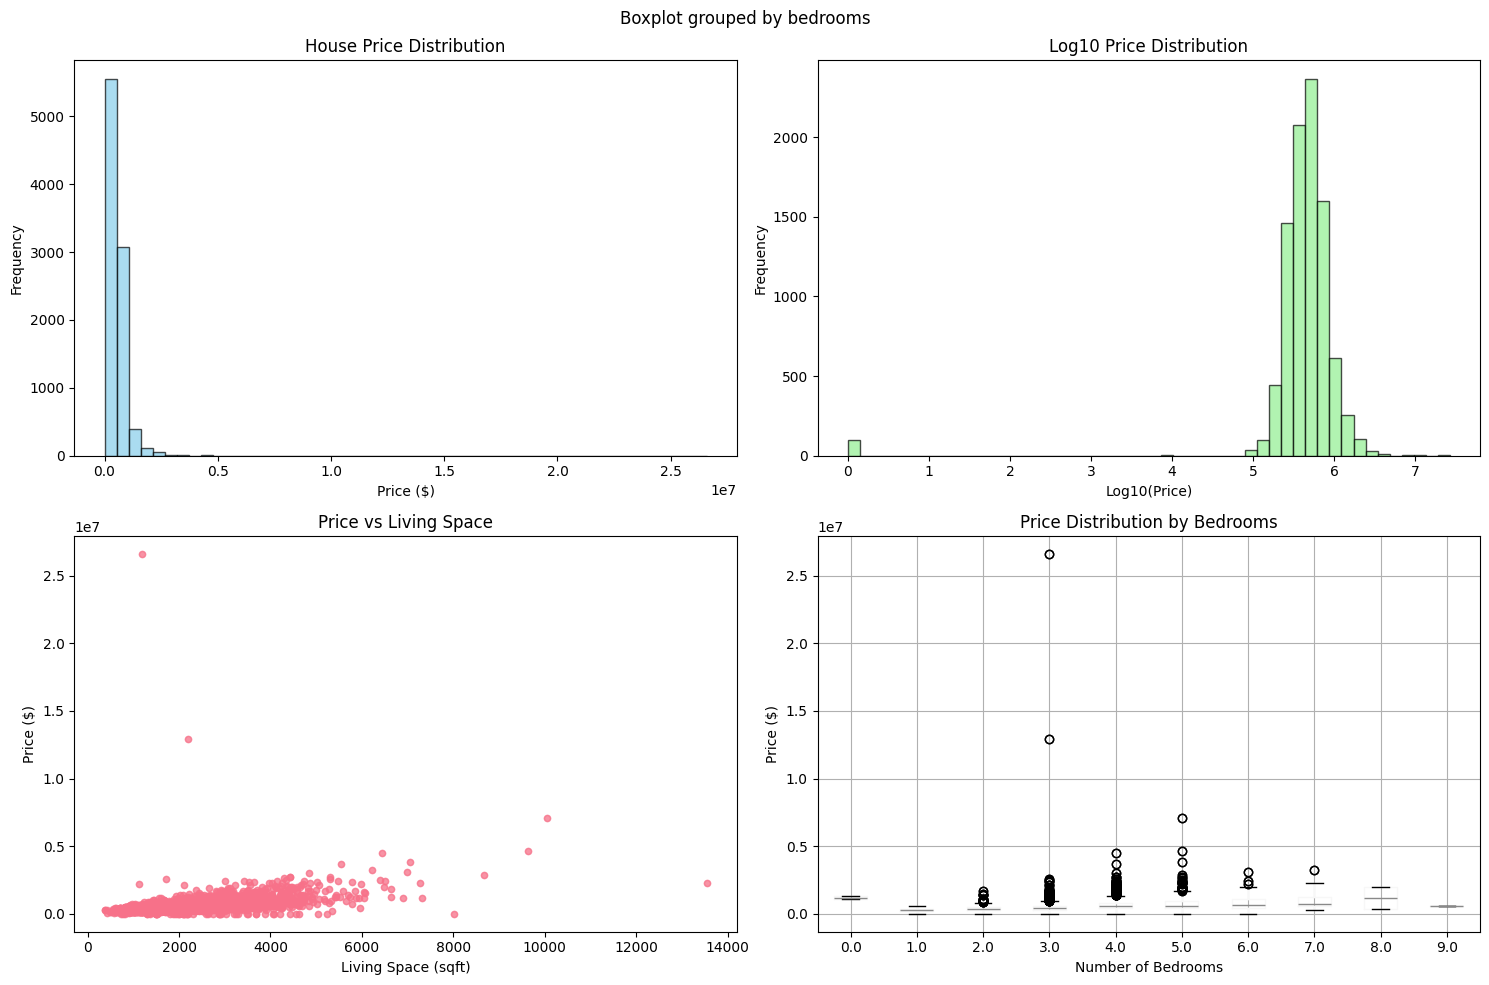

In [79]:
#DATA EXPLORATION
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
fig_size = (15, 10)

# 1. Price Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=fig_size)

# Price histogram
axes[0,0].hist(df['price'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('House Price Distribution')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Frequency')

# Log-transformed price (often more normal)
# using log1p instead of log10 to handle zero or negative values if any
# axes[0,1].hist(np.log1p(df['price']), bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].hist(np.log10(df['price']+ 1), bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Log10 Price Distribution')
axes[0,1].set_xlabel('Log10(Price)')
axes[0,1].set_ylabel('Frequency')

# Price vs Living Space
axes[1,0].scatter(df['sqft_living'], df['price'], alpha=0.5, s=20)
axes[1,0].set_title('Price vs Living Space')
axes[1,0].set_xlabel('Living Space (sqft)')
axes[1,0].set_ylabel('Price ($)')

# Boxplot of price by number of bedrooms
df.boxplot(column='price', by='bedrooms', ax=axes[1,1])
axes[1,1].set_title('Price Distribution by Bedrooms')
axes[1,1].set_xlabel('Number of Bedrooms')
axes[1,1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()


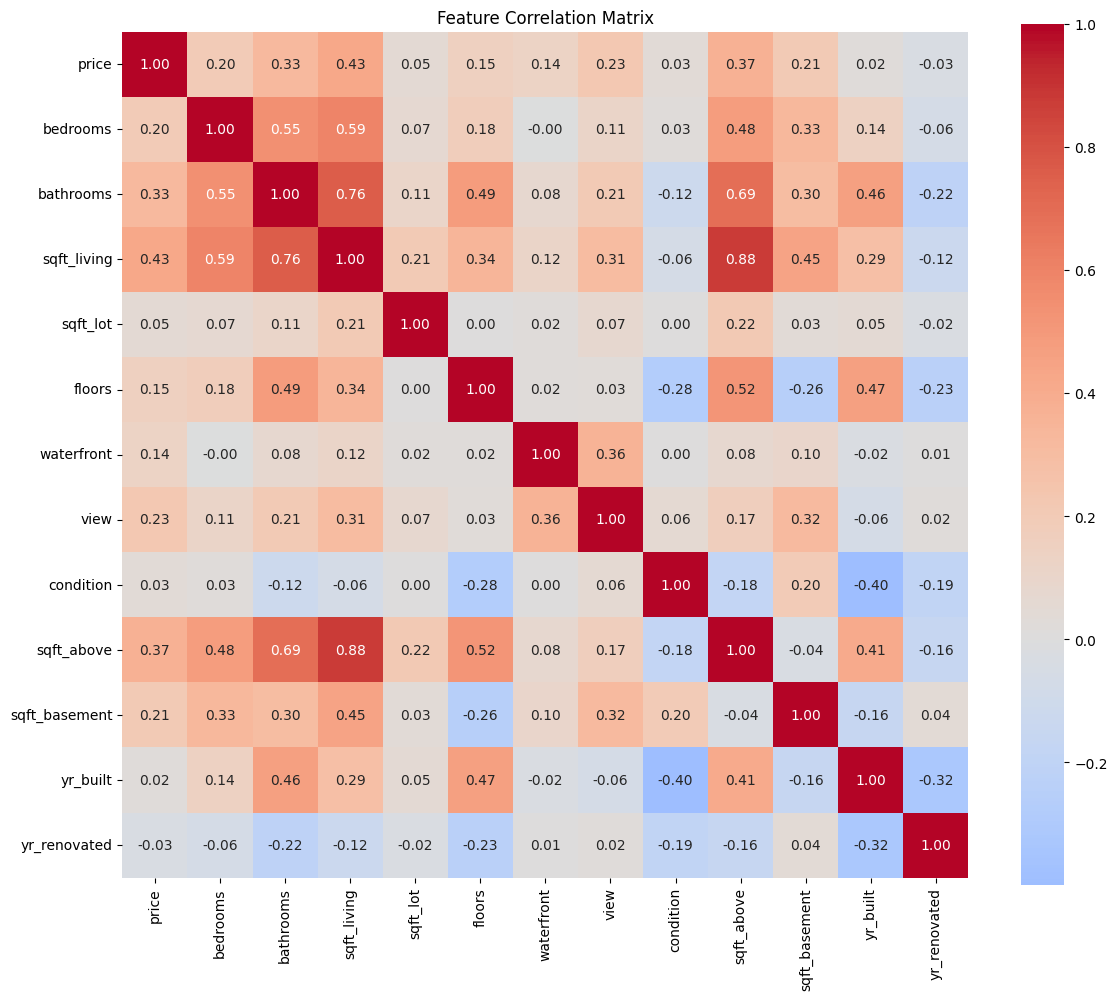


=== TOP PRICE CORRELATIONS ===
sqft_living      0.430366
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_renovated     0.028774
yr_built         0.021857
Name: price, dtype: float64


In [80]:

# Feature Correlation Analysis (numerical features)

# Select numerical columns for correlation
numerical_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
                  'floors', 'waterfront', 'view', 'condition', 'sqft_above', 
                  'sqft_basement', 'yr_built', 'yr_renovated']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Top correlations with price
price_corr = correlation_matrix['price'].abs().sort_values(ascending=False)
print("\n=== TOP PRICE CORRELATIONS ===")
print(price_corr[1:])  # Exclude price correlation with itself


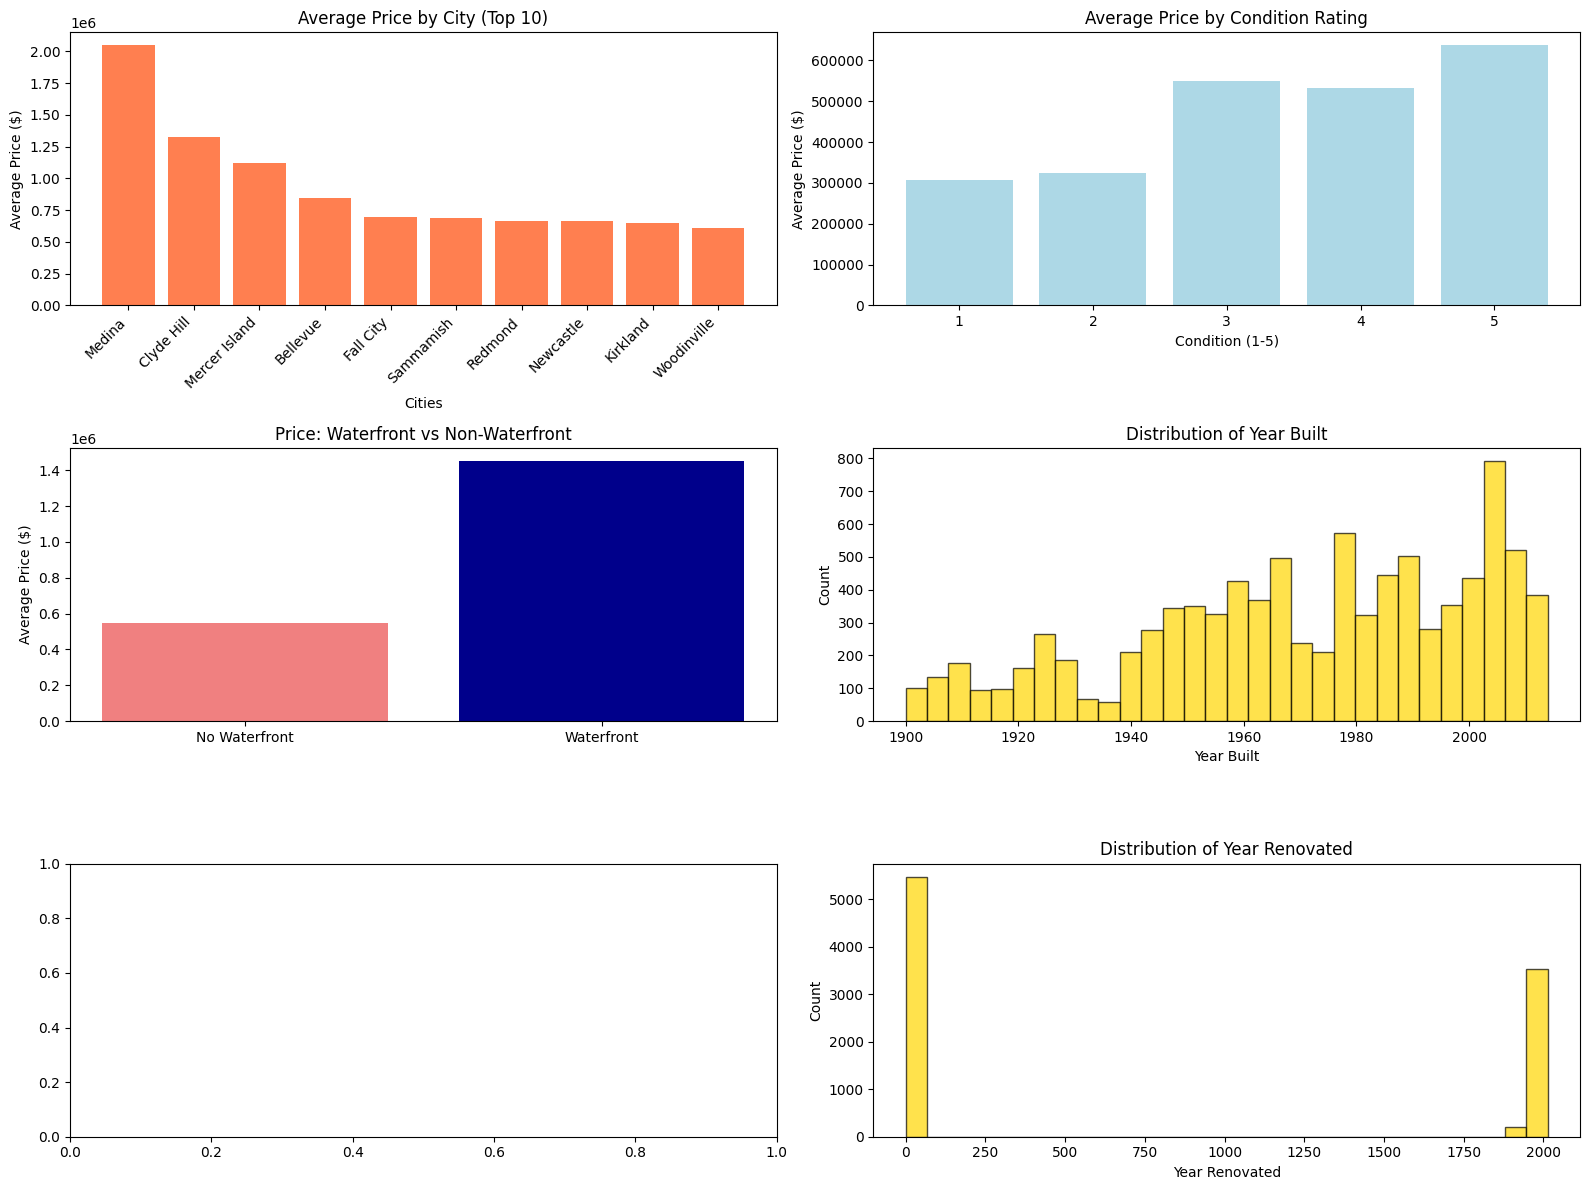

In [83]:
# Geographic and Categorical Analysis
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Price by city
city_prices = df.groupby('city')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_cities = city_prices[city_prices['count'] >= 10].head(10)  # Cities with at least 10 properties

axes[0,0].bar(range(len(top_cities)), top_cities['mean'], color='coral')
axes[0,0].set_title('Average Price by City (Top 10)')
axes[0,0].set_xlabel('Cities')
axes[0,0].set_ylabel('Average Price ($)')
axes[0,0].set_xticks(range(len(top_cities)))
axes[0,0].set_xticklabels(top_cities.index, rotation=45, ha='right')

# Price by condition
condition_prices = df.groupby('condition')['price'].mean().sort_index()
axes[0,1].bar(condition_prices.index, condition_prices.values, color='lightblue')
axes[0,1].set_title('Average Price by Condition Rating')
axes[0,1].set_xlabel('Condition (1-5)')
axes[0,1].set_ylabel('Average Price ($)')

# Waterfront premium
waterfront_prices = df.groupby('waterfront')['price'].mean()
axes[1,0].bar(['No Waterfront', 'Waterfront'], waterfront_prices.values, 
              color=['lightcoral', 'darkblue'])
axes[1,0].set_title('Price: Waterfront vs Non-Waterfront')
axes[1,0].set_ylabel('Average Price ($)')

# Year built distribution
axes[1,1].hist(df['yr_built'], bins=30, alpha=0.7, color='gold', edgecolor='black')
axes[1,1].set_title('Distribution of Year Built')
axes[1,1].set_xlabel('Year Built')
axes[1,1].set_ylabel('Count')

# Year built distribution
axes[2,1].hist(df['yr_renovated'], bins=30, alpha=0.7, color='gold', edgecolor='black')
axes[2,1].set_title('Distribution of Year Renovated')
axes[2,1].set_xlabel('Year Renovated')
axes[2,1].set_ylabel('Count')

plt.tight_layout()
plt.show()
